In [3]:
from run_spectra_fit import *

In [4]:
#%pip install pathlib

# Notebook to plot and fit SEP data

### Table of contents:
* [1) Overview](#1.-Overview)
* [2) Loading the data file](#2.-Loading-the-data-file)
* [3) Fitting the Spectrum](#3.-Fitting-the-Spectrum)


## 1. Overview
This Notebook allows the user to plot and fit energy spectra of SEPs. The fitting is done using Python ODR.
<br>The fit result and plot will be saved to a folder of your choosing
### 1.1 The Mathematical Models:
This notebook allows the user to fit five different mathematical models to the data. 
<br>Single power-law:
<br>$I(E) = I_0 \left(\frac{E}{E_0} \right)^{\gamma_1}$
<br>Double power-law:
<br>$I(E) = I_0 \left(\frac{E}{E_0} \right)^{\gamma _1} \left(\frac{E^{\alpha}+E^{\alpha}_{\rm b}}{E^{\alpha} _0+E^{\alpha}_{\rm b}} \right)^{\frac{\gamma_2 -\gamma_1}{\alpha}}$
<br>Single power-law with exponential cut-off:
<br>$I(E) = I_0 \left(\frac{E}{E_0} \right)^{\gamma _1} e^{-\left( \frac{E}{E_{\rm c}} \right)^x }$
<br>Double power-law with exponential cut-off
<br>$I(E) = I_0 \left(\frac{E}{E_0} \right)^{\gamma _1}  \left(\frac{E^{\alpha}+E^{\alpha}_{\rm b}}{E^{\alpha} _0+E^{\alpha}_{\rm b}} \right)^{\frac{\gamma_2 -\gamma_1}{\alpha}} e^{-\left( \frac{E}{E_{\rm c}} \right)^x }$
<br>Triple power-law:
<br>$I(E) = I_0 \left(\frac{E}{E_0} \right)^{\gamma _1}  \left(\frac{E^{\alpha}+E^{\alpha}_{\rm bl}}{E^{\alpha} _0+E^{\alpha}_{\rm bl}} \right)^{\frac{\gamma_2 -\gamma_1}{\alpha}} \left(\frac{E^{\beta}+E^{\beta}_{\rm bh}}{E^{\beta} _0+E^{\beta}_{\rm bh}} \right)^{\frac{\gamma_3 -\gamma_2}{\beta}}$
<br> The user can choose to fit either a specific model or a combination of them to the data. The software will compare the reduced $\chi²$  values for each fit and output the best one. The lower the reduced $\chi²$ value, the better the fit.
<br>$\textbf{NOTE}$: when choosing a specific type of model to fit, if the data cannot be fit with that model, the software will still produce an output with the next best model.

## 2. Loading the data file

<br> provide the path to the file. The file can be in either txt or csv format. If the data is in xlsx format use pd.read_excel() instead of pd.read_csv(). The fit output (plot and variables resulting from the fit) will be saved in the same folder as your data file. The name of the output files will be based on the name of the provided file. 
<br> $\textbf{NOTE}$: the file should have the following column names: 'Energy', 'Intensity', 'E_err', 'I_err'
<br> The file can contain other columns as well, but should have energy and intensity/flux data named as mentioned. 'E_err' and 'I_err' can be empty columns in case there are no energy or intensity uncertainties. 

### NINA: I think the user should be able to omit  'E_err' and 'I_err' from the files if there are no uncertainties, no? Maybe there should be a key work input that says no to uncertainties?


In [5]:
#path_to_file = r'C:/Users/Omistaja/Desktop/SRL/2021SRL/messenger/event1.txt'
path =  r'/home/annafed/Documents/SOLER/nan_exaple_WIND.csv'
data = pd.read_csv(path) # or pd.read_excel() for xlsx data


## 3. Fitting the Spectrum

### 3.1 Choose the type of fit
The user can choose to either fit a specific model or combination of models to the data.
$\textbf{which\_fit}$ options: 
<br> '$\textbf{single}$' will force a single pl fit to the data
<br> '$\textbf{broken}$' will force a broken pl fit to the data but ONLY if the break point is within the energy range otherwise a sigle pl fit will be produced instead
<br> '$\textbf{best\_sb}$' will choose automatically the best fit type between single and broken by comparing the redchis of the fits
<br> '$\textbf{cut}$' will produce a single pl fit with an exponential cutoff point. If the cutoff point is outside of the energy range a broken or single pl will be fit instead
<br> '$\textbf{broken\_cut}$' will produce a broken pl fit with an exponential cutoff point. If the cutoff point is outside of the energy range a broken or single pl will be fit instead
<br> '$\textbf{best\_cb}$' will choose the better option between a broken pl and a single+cutoff. If the break and cutoff points are outside of the energy range a single pl will be fit instead.
<br>'$\textbf{triple}$' will try to fit a triple pl. If not possible, will try to fit the next best option.
<br> '$\textbf{best}$' will choose automatically the best fit type by comparing the redchis of the fits


In [5]:
which_fit = 'best' # will be deleted, it's better to have it lower where the guess values are

### 3.2 Guess values and energy range
Here the user can input guess values for each of the fitiing variables. The inputs should be physical and based on the knowledge of previously studied SEP spectra.

<br> You can choose to restrict the energy range that will be fit by changing e_min and e_max. If None, the full available energy range will be fit.
<br> $\textbf{e\_min}$ Lower limit for the energy range to fit. Input in MeV, defautls to None. 
<br> $\textbf{e\_max}$ Upper limit for the energy range to fit. Input in MeV, defautls to None.

<br> $\textbf{g1\_guess}$  spectral index before the break (or single pl). Defaults to
<br> $\textbf{g2\_guess}$  spectral index after the first spectral break (for broken pl, broken pl + exp. cut-off, triple pl)  Defaults to
<br> $\textbf{g3\_guess}$  spectral index after the second break (for triple pl)  Defaults to
<br> $\textbf{c1\_guess}$  Intensity value at 100 keV.  Defaults to $\textbf{NOTE}$: try to estimate the intensity at 100 keV. If the fit fails, it often depends on this input parameter. 
<br> $\textbf{alpha\_guess}$ sharpness of the first break.  Defaults to
<br> $\textbf{beta\_guess}$ sharpness of the second break.  Defaults to
<br> $\textbf{break\_guess\_low}$ guess value for the first spectral break. Input in MeV.  Defaults to
<br> $\textbf{break\_guess\_high}$ guess value for the second spectral break. Input in MeV.  Defaults to
<br> $\textbf{cut\_guess}$ guess value for the exponential cut-off energy. Input in MeV.  Defaults to


In [6]:
e_min =  None # in MeV 
e_max = None# in MeV

g1_guess = -1.9 # gamma 1 -> spectral index before the break (or single pl)
g2_guess = -2.5 # gamma 2 -> spectral index after the break (for broken pl)
g3_guess = -4.5 # gamma 3 -> spectral index after the second break (for triple pl)
c1_guess = 1e4 # peak flux
alpha_guess = 7.16 # sharpness of the first break
beta_guess = 10 #sharpness of the second break
break_guess_low = 0.06 #in MeV
break_guess_high = 0.12
cut_guess = 0.12 #in MeV


### 3.3 other input variables

<br>Random and iterations
<br>if use_random = False the fit will only be made once with the guess values
<br> if use_random = True the fitting function will first create a list of reasonable values for each of the fitting parameters then randomly select values from the lists and compare the redchis of each fit to find the best one
<br> iterations = number of times the fit is retried to find the best one


In [6]:
#legend_details = False

use_random = True 
iterations = 100

which_fit = 'single' 
exclude_channels = [1,3]

In [7]:
save = True

In [8]:
plot_title = 'SOLER DATA TEST'
x_label = 'Energy (MeV)'
y_label = 'Intensity\n/(s cm² sr MeV)'
legend_title = '' 

use_filename_as_title = False

/home/annafed/Documents/GitHub/SolOEPD-Plot-n-Fit-SEE/my_power_law_fits_odr.py:207: RuntimeWarning: invalid value encountered in power
  y = c1*(x/0.1)**gamma1


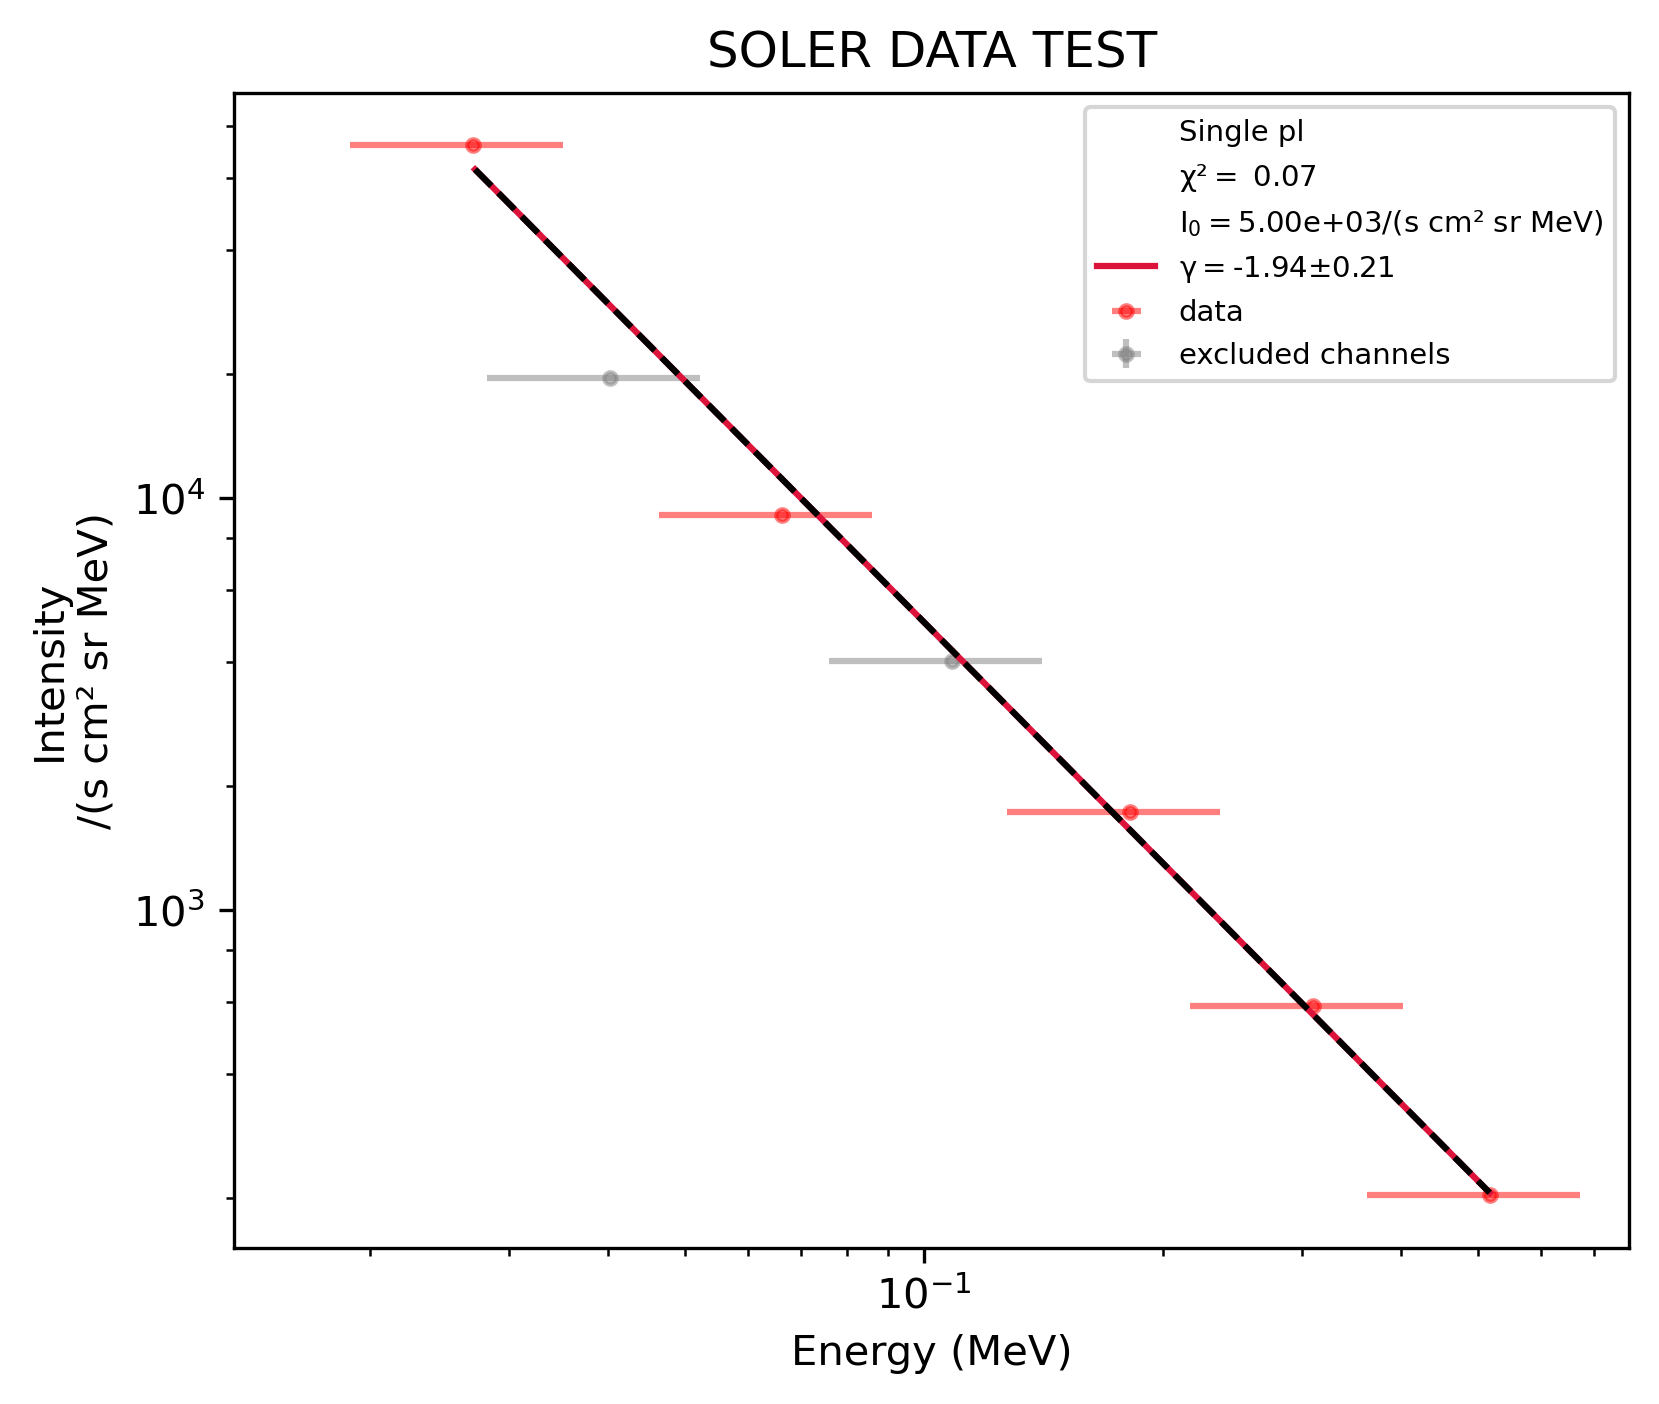

In [9]:
# WILL ADD THE PRINT FOR THE FIT VALUES ETC
run_the_fit(path, data, save, use_filename_as_title, channels_to_exclude = exclude_channels, plot_title = plot_title, x_label = x_label, y_label = y_label, legend_title = legend_title, which_fit = which_fit,  e_min = e_min, e_max = e_max, g1_guess =g1_guess, g2_guess = g2_guess, g3_guess = g3_guess, c1_guess = c1_guess, alpha_guess = alpha_guess, beta_guess = beta_guess, break_guess_low = break_guess_low, break_guess_high = break_guess_high, cut_guess = cut_guess, use_random = use_random, iterations = iterations , legend_details = True)
           